 Extracting longitudinal radiomic sequences...
 Building integrated VHT Patient objects...


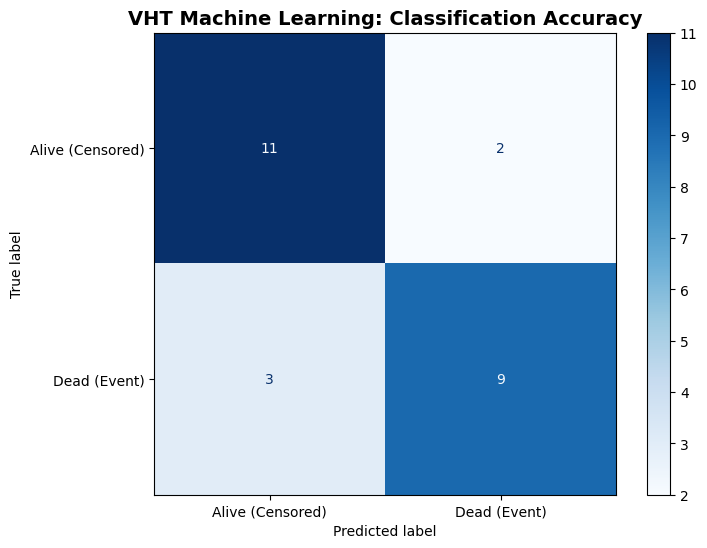

 VHT Matrix Complete: 178 components explain 99% variance.

 TOP DRIVERS OF VHT SIGNATURE (PC1):
Index(['Cycle length of Additional Therapy (q days)', 'Number of Fractions',
       'Number of Days from Diagnosis to Starting Additional Therapy ',
       'Number of days from Diagnosis to date of Further Progression',
       'Number of Days from Diagnosis to Starting 2nd_Additional Therapy ',
       'Multiple surgeries',
       'Number of Days from Diagnosis to Start Immunotherapy ',
       'Days from Diagnosis to new treatment',
       ' Number of days from Diagnosis to Initial Chemo Therapy end date',
       'Number of days from Diagnosis to date of First Progression',
       'Number of days from Diagnosis to Radiation Therapy end date',
       'Number of Days from Diagnosis to the day of Insertion of Brachytherapy ',
       ' Number of days from Diagnosis to Initial Chemo Therapy Start date',
       'Grade of Primary Brain Tumor',
       'Number of days from Diagnosis to Radiation Ther

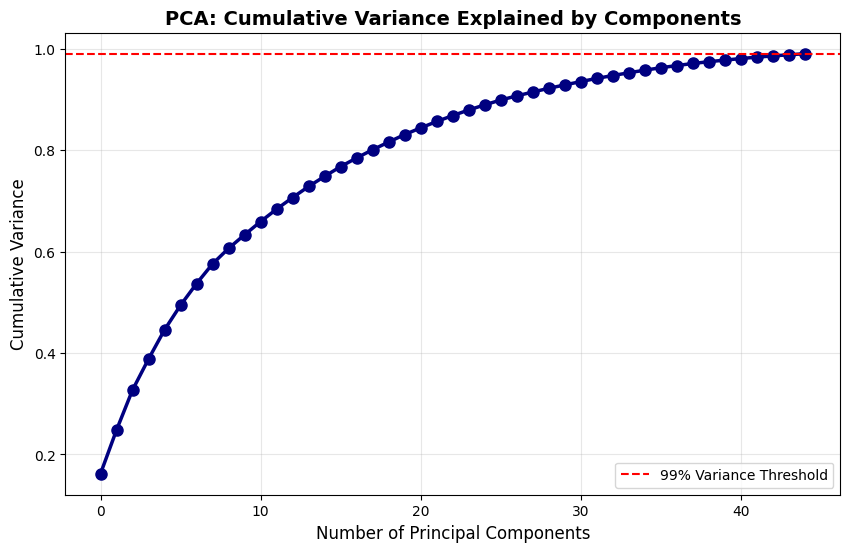

/var/folders/b9/x77syzb94gdggfcpp713pvjm0000gn/T/ipykernel_37501/1579987653.py:193: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=pc1_loadings.head(20).index, x=pc1_loadings.head(20).values, palette='viridis')


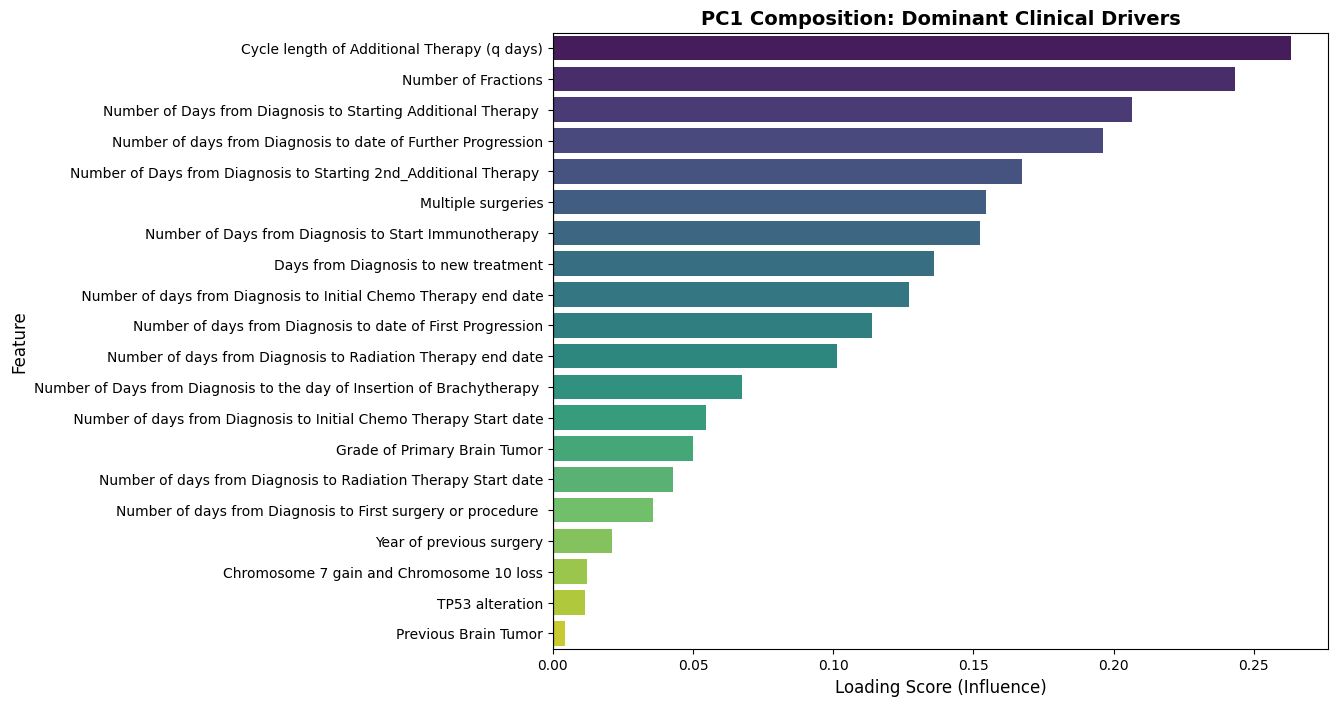

<lifelines.CoxPHFitter: fitted with 203 total observations, 106 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 203
number of events observed = 97
   partial log-likelihood = -316.58
         time fit was run = 2026-05-27 16:09:34 UTC

---
                                                                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                                                
Sex at Birth                                                            -0.09      0.91      0.24           -0.57            0.39                0.57                1.48
Race                                                                    -0.46      0.63      0.41           -1.26            0.34                0.28                1.40
Age at diagnosis                                                         0.00      1.00      0.01           -0.01            0.02                0.99                1.02
Primary Diagnosis                                                       -0.01      0.99      0.21           -0.41            0.40                0.66                1.48
Grade of Primary Brain Tumor                                             0.04      1.04      0.24           -0.43            0.50                0.65                1.65
Stereotactic Biopsy before Surgical Resection                            0.69      1.98      0.49           -0.27            1.64                0.76                5.16
Multiple surgeries                                                      -0.50      0.61      0.28           -1.05            0.05                0.35                1.05
IDH1 mutation                                                            0.23      1.26      0.30           -0.36            0.82                0.70                2.26
IDH2 mutation                                                            0.07      1.08      0.24           -0.39            0.54                0.67                1.72
1p/19q                                                                   0.03      1.03      0.03           -0.03            0.09                0.97                1.09
ATRX mutation                                                           -0.04      0.96      0.08           -0.19            0.11                0.82                1.11
MGMT methylation                                                        -0.16      0.85      0.09           -0.35            0.02                0.71                1.02
BRAF V600E mutation                                                      0.11      1.11      0.64           -1.15            1.37                0.32                3.92
TERT promoter mutation                                                   0.01      1.01      0.33           -0.64            0.66                0.53                1.94
Chromosome 7 gain and Chromosome 10 loss                                -0.63      0.53      0.55           -1.70            0.45                0.18                1.56
H3-3A mutation                                                          -0.02      0.98      0.24           -0.49            0.44                0.61                1.55
EGFR amplification                                                       0.35      1.42      0.51           -0.65            1.35                0.52                3.87
PTEN mutation                                                            0.04      1.04      0.56           -1.06            1.14                0.35                3.11
CDKN2A/B deletion                                                        0.14      1.15      0.65           -1.14            1.41                0.32                4.09
TP53 a

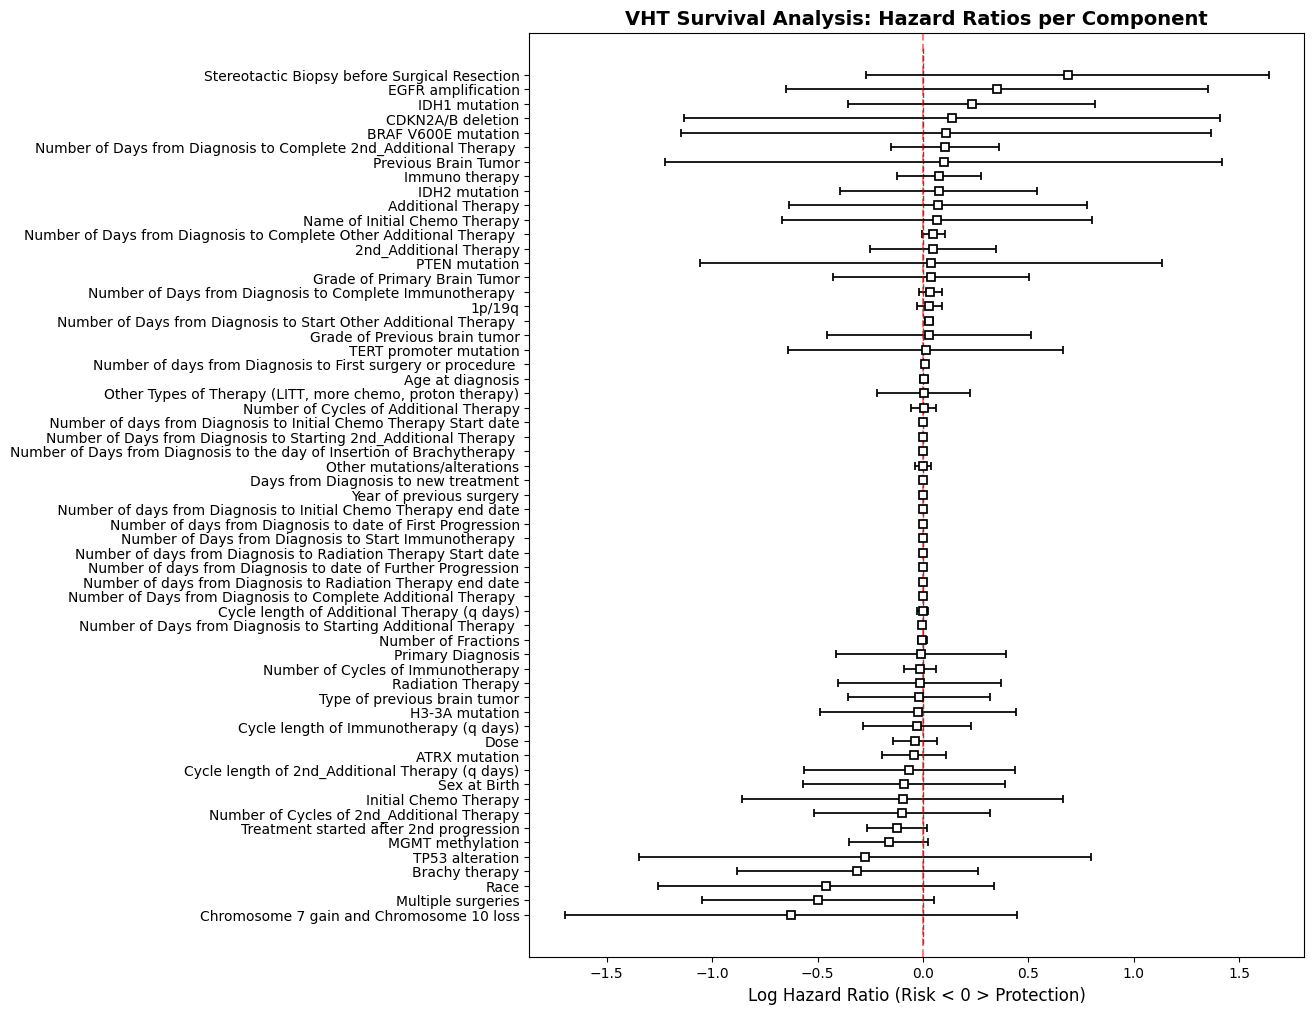

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from lifelines import CoxPHFitter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# ======================================================================================
# 1. SETUP & LONGITUDINAL EXTRACTION
# ======================================================================================
image_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post")
seg_vol_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx")
clinical_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx")

segmentation_labels = {1: "Necrotic", 2: "Edema", 3: "Enhancing", 4: "Resection"}
label_map = {
    "Necrotic Tumor Core (Label1)": "Necrotic",
    "Tumor Infiltration and Edema": "Edema",
    "Enhancing Tumor Core (Label3)": "Enhancing",
    "Resection Cavity (Label4)": "Resection"
}


def safe_numeric(s, default=np.nan):
    return pd.to_numeric(s, errors='coerce').fillna(default) if isinstance(s, pd.Series) else s


# ======================================================================================
# 2. LOAD RADIOMIC MASTER SEQUENCES
# ======================================================================================
print(" Extracting longitudinal radiomic sequences...")
m_dict = {k: {} for k in ['vol', 'vox', 't1cm', 't1cs', 't1nm', 't1ns', 't2fm', 't2fs', 't2wm', 't2ws']}

seg_file = pd.ExcelFile(seg_vol_path)
for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()

    if 'Patient ID' not in df.columns:
        continue

    df['PID_Clean'] = df['Patient ID'].astype(str).str.split('-').str[0]
    label_key = label_map.get(sheet, sheet)
    group = df.groupby('PID_Clean')

    cols = list(df.columns)
    if len(cols) < 13:
        continue

    m_dict['vox'][label_key]  = group[cols[3]].apply(list).to_dict()
    m_dict['vol'][label_key]  = group[cols[4]].apply(list).to_dict()
    m_dict['t1cm'][label_key] = group[cols[5]].apply(list).to_dict()
    m_dict['t1cs'][label_key] = group[cols[6]].apply(list).to_dict()
    m_dict['t1nm'][label_key] = group[cols[7]].apply(list).to_dict()
    m_dict['t1ns'][label_key] = group[cols[8]].apply(list).to_dict()
    m_dict['t2fm'][label_key] = group[cols[9]].apply(list).to_dict()
    m_dict['t2fs'][label_key] = group[cols[10]].apply(list).to_dict()
    m_dict['t2wm'][label_key] = group[cols[11]].apply(list).to_dict()
    m_dict['t2ws'][label_key] = group[cols[12]].apply(list).to_dict()

clinical_df = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
clinical_df['PID_Clean'] = clinical_df['Patient ID'].astype(str).str.split('-').str[0]
clinical_data = clinical_df.set_index('PID_Clean').to_dict(orient='index')

patient_ids = sorted([d for d in os.listdir(image_path) if (image_path / d).is_dir() and not d.startswith('.')])
patient_objects = {}

print(" Building integrated VHT Patient objects...")
for pid in patient_ids:
    clean_id = pid.split('-')[0]
    p_folder = image_path / pid
    tps = sorted([t.name for t in p_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])

    obj = {
        'Patient_ID': pid,
        'PID_Clean': clean_id,
        'clinical': clinical_data.get(clean_id, {}),
        'timepoints': tps,
        'images': {}, 'volumes': {}, 'voxels': {},
        't1c_mean': {}, 't1c_stdevs': {}, 't1n_mean': {}, 't1n_stdevs': {},
        't2f_mean': {}, 't2f_stdevs': {}, 't2w_mean': {}, 't2w_stdevs': {}
    }

    for i, tp in enumerate(tps):
        obj['images'][tp] = [str(f) for f in (p_folder / tp).glob("*.nii*")]
        for l_name in m_dict['vol'].keys():
            def get_val(key):
                seq = m_dict[key].get(l_name, {}).get(clean_id, [])
                return seq[i] if i < len(seq) else 0

            obj['volumes'].setdefault(tp, {})[l_name] = float(get_val('vol'))
            obj['voxels'].setdefault(tp, {})[l_name] = int(get_val('vox'))
            obj['t1c_mean'].setdefault(tp, {})[l_name] = float(get_val('t1cm'))
            obj['t1c_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1cs'))
            obj['t1n_mean'].setdefault(tp, {})[l_name] = float(get_val('t1nm'))
            obj['t1n_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1ns'))
            obj['t2f_mean'].setdefault(tp, {})[l_name] = float(get_val('t2fm'))
            obj['t2f_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2fs'))
            obj['t2w_mean'].setdefault(tp, {})[l_name] = float(get_val('t2wm'))
            obj['t2w_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2ws'))

    patient_objects[pid] = obj


# ======================================================================================
# 3. MERGING & CLEANING FOR ML
# ======================================================================================
df_vht = clinical_df.copy()

targets = ['Overall Survival (Death)', 'Number of days from Diagnosis to death (Days)']
exclude = targets + [
    'Patient ID', 'PID_Clean', 'Hospice', 'Time to First Progression (Days)', 'Progression',
    'Type of 1st Progression', 'Second Progression/Recurrence', 'Type of 2nd Progression',
    'Number of Days from Diagnosis to 1st MRI (Timepoint_1) ',
    'Number of Days from Diagnosis to 2nd MRI (Timepoint_2) ',
    'Number of Days from Diagnosis to 3rd MRI (Timepoint_3) ',
    'Number of Days from Diagnosis to 4th MRI (Timepoint_4) ',
    'Number of Days from Diagnosis to 5th MRI (Timepoint_5) ',
    'Number of Days from Diagnosis to 6th MRI (Timepoint_6) '
]

X_raw = df_vht.drop(columns=[c for c in exclude if c in df_vht.columns]).copy()

for col in X_raw.select_dtypes(include=['object']).columns:
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col].astype(str))
X_raw = X_raw.fillna(0)

y_labels = pd.to_numeric(df_vht[targets[0]], errors='coerce').fillna(0).astype(int)
surv_duration = pd.to_numeric(df_vht[targets[1]], errors='coerce').fillna(1).astype(float)
surv_event = y_labels.copy()

valid_rows = np.isfinite(surv_duration.values)
X_raw = X_raw.loc[valid_rows].reset_index(drop=True)
y_labels = y_labels.loc[valid_rows].reset_index(drop=True)
surv_duration = surv_duration.loc[valid_rows].reset_index(drop=True)
surv_event = surv_event.loc[valid_rows].reset_index(drop=True)
df_vht = df_vht.loc[valid_rows].reset_index(drop=True)

X_train_raw, X_test_raw, y_train, y_test, dur_train, dur_test, evt_train, evt_test = train_test_split(
    X_raw, y_labels, surv_duration, surv_event,
    test_size=0.12, random_state=42, stratify=y_labels
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

pca = PCA(n_components=0.99, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

clf_pca = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
clf_pca.fit(X_train_pca, y_train)

y_pred = clf_pca.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alive (Censored)', 'Dead (Event)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('VHT Machine Learning: Classification Accuracy', fontsize=14, fontweight='bold')
plt.show()


# ======================================================================================
# 4. VHT SIGNATURE ANALYSIS (PCA)
# ======================================================================================
print(f" VHT Matrix Complete: {X_train_pca.shape[0]} components explain 99% variance.")

pc1_drivers = pd.Series(pca.components_[0], index=X_raw.columns).sort_values(ascending=False)
print("\n TOP DRIVERS OF VHT SIGNATURE (PC1):")
print(pc1_drivers.head(20).index)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'o-', color='navy', linewidth=2.5, markersize=8)
plt.axhline(y=0.99, color='red', linestyle='--', label='99% Variance Threshold')
plt.title('PCA: Cumulative Variance Explained by Components', fontsize=14, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Variance', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 8))
pc1_loadings = pd.Series(pca.components_[0], index=X_raw.columns).sort_values(ascending=False)
sns.barplot(y=pc1_loadings.head(20).index, x=pc1_loadings.head(20).values, palette='viridis')
plt.title('PC1 Composition: Dominant Clinical Drivers', fontsize=14, fontweight='bold')
plt.xlabel('Loading Score (Influence)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8)
plt.show()


# ======================================================================================
# 5. SURVIVAL MODELING (COX PCA)
# ======================================================================================
df_cox_pca = pd.DataFrame(X_raw.values, columns=X_raw.columns)
df_cox_pca['duration'] = surv_duration.values
df_cox_pca['event'] = surv_event.values

cox_df = df_cox_pca.drop(columns=[], errors='ignore').copy()
cox_df = cox_df.select_dtypes(include=[np.number]).copy()
cox_df = cox_df.dropna(subset=['duration', 'event'])
cox_df = cox_df[cox_df['duration'] > 0]

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df, duration_col='duration', event_col='event')
cph.print_summary()

plt.figure(figsize=(10, 12))
cph.plot()
plt.title('VHT Survival Analysis: Hazard Ratios per Component', fontsize=14, fontweight='bold')
plt.xlabel('Log Hazard Ratio (Risk < 0 > Protection)', fontsize=12)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

In [2]:
import nibabel as nib
from pathlib import Path

# If these are not already imported in your notebook:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.multioutput import MultiOutputRegressor

image_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post")
seg_vol_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx")
clinical_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx")

# ======================================================================================
# 1. LOAD RADIOMIC MASTER SEQUENCES (Ordered by Patient/Visit)
# ======================================================================================
print(" Extracting longitudinal radiomic sequences...")
m_dict = {k: {} for k in ['vol', 'vox', 't1cm', 't1cs', 't1nm', 't1ns', 't2fm', 't2fs', 't2wm', 't2ws']}

seg_file = pd.ExcelFile(seg_vol_path)
for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()

    if 'Patient ID' not in df.columns or len(df.columns) < 13:
        continue

    df['PID_Clean'] = df['Patient ID'].astype(str).str.split('-').str[0]
    label_key = label_map.get(sheet, sheet)
    group = df.groupby('PID_Clean')

    m_dict['vox'][label_key]  = group[df.columns[3]].apply(list).to_dict()
    m_dict['vol'][label_key]  = group[df.columns[4]].apply(list).to_dict()
    m_dict['t1cm'][label_key] = group[df.columns[5]].apply(list).to_dict()
    m_dict['t1cs'][label_key] = group[df.columns[6]].apply(list).to_dict()
    m_dict['t1nm'][label_key] = group[df.columns[7]].apply(list).to_dict()
    m_dict['t1ns'][label_key] = group[df.columns[8]].apply(list).to_dict()
    m_dict['t2fm'][label_key] = group[df.columns[9]].apply(list).to_dict()
    m_dict['t2fs'][label_key] = group[df.columns[10]].apply(list).to_dict()
    m_dict['t2wm'][label_key] = group[df.columns[11]].apply(list).to_dict()
    m_dict['t2ws'][label_key] = group[df.columns[12]].apply(list).to_dict()

clinical_df = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
clinical_df['PID_Clean'] = clinical_df['Patient ID'].astype(str).str.split('-').str[0]
clinical_data = clinical_df.set_index('PID_Clean').to_dict(orient='index')

patient_ids = sorted([d for d in os.listdir(image_path) if (image_path / d).is_dir() and not d.startswith('.')])
patient_objects = {}

print(" Building integrated VHT Patient objects...")
for pid in patient_ids:
    clean_id = pid.split('-')[0]
    p_folder = image_path / pid
    tps = [t.name for t in p_folder.iterdir() if t.is_dir() and not t.name.startswith('.')]

    if len(tps) < 2:
        continue

    def tp_index(tp):
        digits = ''.join(filter(str.isdigit, tp))
        return int(digits) if digits else 10**9

    tps = sorted(tps, key=tp_index)

    obj = {
        'Patient_ID': pid,
        'PID_Clean': clean_id,
        'clinical': clinical_data.get(clean_id, {}),
        'timepoints': tps,
        'images': {}, 'volumes': {}, 'voxels': {},
        't1c_mean': {}, 't1c_stdevs': {}, 't1n_mean': {}, 't1n_stdevs': {},
        't2f_mean': {}, 't2f_stdevs': {}, 't2w_mean': {}, 't2w_stdevs': {}
    }

    for i, tp in enumerate(tps):
        obj['images'][tp] = [str(f) for f in (p_folder / tp).glob("*.nii*")]

        for l_name in m_dict['vol'].keys():
            def get_val(key):
                seq = m_dict[key].get(l_name, {}).get(clean_id, [])
                return seq[i] if i < len(seq) else 0

            obj['volumes'].setdefault(tp, {})[l_name] = float(get_val('vol'))
            obj['voxels'].setdefault(tp, {})[l_name] = int(get_val('vox'))
            obj['t1c_mean'].setdefault(tp, {})[l_name] = float(get_val('t1cm'))
            obj['t1c_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1cs'))
            obj['t1n_mean'].setdefault(tp, {})[l_name] = float(get_val('t1nm'))
            obj['t1n_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1ns'))
            obj['t2f_mean'].setdefault(tp, {})[l_name] = float(get_val('t2fm'))
            obj['t2f_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2fs'))
            obj['t2w_mean'].setdefault(tp, {})[l_name] = float(get_val('t2wm'))
            obj['t2w_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2ws'))

    patient_objects[pid] = obj

 Extracting longitudinal radiomic sequences...
 Building integrated VHT Patient objects...


In [9]:
# ======================================================================================
# 2. ENHANCED FEATURE ENGINEERING: BIOLOGICAL PRIORS & TREATMENT MODIFIERS
# ======================================================================================
print("Extracting Treatment Exposures & Molecular Priors for VHT Calibration...")

from sklearn.preprocessing import LabelEncoder

biological_priors = [
    'IDH1 mutation', 'IDH2 mutation', 'MGMT methylation', '1p/19q',
    'ATRX mutation', 'BRAF V600E mutation', 'TERT promoter mutation',
    'Chromosome 7 gain and Chromosome 10 loss', 'H3-3A mutation',
    'EGFR amplification', 'PTEN mutation', 'CDKN2A/B deletion',
    'TP53 alteration', 'Grade of Primary Brain Tumor'
]

treatment_columns = [
    'Initial Chemo Therapy', 'Radiation Therapy', 'Dose', 'Number of Fractions',
    'Additional Therapy', '2nd_Additional Therapy', 'Immuno therapy', 'Brachy therapy',
    'Cycle length of Additional Therapy (q days)',
    'Number of Days from Diagnosis to Starting Additional Therapy',
    'Number of Days from Diagnosis to Starting 2nd_Additional Therapy',
    'Number of Days from Diagnosis to Start Immunotherapy',
    'Number of days from Diagnosis to Initial Chemo Therapy Start date',
    'Number of days from Diagnosis to Radiation Therapy Start date'
]

def safe_mean(x):
    x = np.asarray(list(x), dtype=float)
    return float(np.nanmean(x)) if x.size else 0.0

def safe_delta(now, prev, dt):
    if pd.isna(now) or pd.isna(prev) or pd.isna(dt) or dt <= 0:
        return np.nan
    return (float(now) - float(prev)) / float(dt)

def get_tp_index(tp):
    digits = ''.join(filter(str.isdigit, str(tp)))
    return int(digits) if digits else 10**9

def get_clinical_day(clinical, tp):
    tp_num = ''.join(filter(str.isdigit, str(tp)))
    if not tp_num:
        return np.nan
    matches = [k for k in clinical.keys() if f"Timepoint_{tp_num}" in str(k)]
    if not matches:
        return np.nan
    val = clinical.get(matches[0], np.nan)
    try:
        return float(val)
    except Exception:
        return np.nan

def get_numeric(clinical, key):
    val = clinical.get(key, np.nan)
    return pd.to_numeric(val, errors='coerce')

intensity_weights = {
    'Necrotic':  {'T1C': 0.10, 'T1N': 0.30, 'T2F': 0.30, 'T2W': 0.30},
    'Edema':     {'T1C': 0.10, 'T1N': 0.15, 'T2F': 0.40, 'T2W': 0.35},
    'Enhancing': {'T1C': 0.50, 'T1N': 0.15, 'T2F': 0.20, 'T2W': 0.15},
    'Resection': {'T1C': 0.35, 'T1N': 0.25, 'T2F': 0.20, 'T2W': 0.20},
}

heterogeneity_weights = {
    'Necrotic':  {'T1C': 0.15, 'T1N': 0.25, 'T2F': 0.30, 'T2W': 0.30},
    'Edema':     {'T1C': 0.10, 'T1N': 0.15, 'T2F': 0.40, 'T2W': 0.35},
    'Enhancing': {'T1C': 0.45, 'T1N': 0.20, 'T2F': 0.20, 'T2W': 0.15},
    'Resection': {'T1C': 0.30, 'T1N': 0.25, 'T2F': 0.20, 'T2W': 0.25},
}

kinetic_features = []

for pid, obj in patient_objects.items():
    clean_id = obj.get('PID_Clean', pid.split('-')[0])
    clinical = obj.get('clinical', {})
    history = None

    chemo_startday = get_numeric(clinical, ' Number of days from Diagnosis to Initial Chemo Therapy Start date')
    chemo_endday = get_numeric(clinical, ' Number of days from Diagnosis to Initial Chemo Therapy end date')

    rad_startday = get_numeric(clinical, 'Number of days from Diagnosis to Radiation Therapy Start date')
    rad_endday = get_numeric(clinical, 'Number of days from Diagnosis to Radiation Therapy end date')

    immuno_cycle = get_numeric(clinical, 'Cycle length of Immunotherapy (q days)')
    immuno_startday = get_numeric(clinical, 'Number of Days from Diagnosis to Start Immunotherapy')
    immuno_endday = get_numeric(clinical, 'Number of Days from Diagnosis to Complete Immunotherapy')

    brachy_startday = get_numeric(clinical, 'Number of Days from Diagnosis to the day of Insertion of Brachytherapy ')

    burden_rates = {f"Vel_{lbl}": [] for lbl in label_map.values()}
    voxel_rates = {f"VoxelVel_{lbl}": [] for lbl in label_map.values()}
    t1c_mean_rates = {f"T1CMeanVel_{lbl}": [] for lbl in label_map.values()}
    t1c_std_rates = {f"T1CStdVel_{lbl}": [] for lbl in label_map.values()}
    t1n_mean_rates = {f"T1NMeanVel_{lbl}": [] for lbl in label_map.values()}
    t1n_std_rates = {f"T1NStdVel_{lbl}": [] for lbl in label_map.values()}
    t2f_mean_rates = {f"T2FMeanVel_{lbl}": [] for lbl in label_map.values()}
    t2f_std_rates = {f"T2FStdVel_{lbl}": [] for lbl in label_map.values()}
    t2w_mean_rates = {f"T2WMeanVel_{lbl}": [] for lbl in label_map.values()}
    t2w_std_rates = {f"T2WStdVel_{lbl}": [] for lbl in label_map.values()}

    tps = sorted(obj.get('timepoints', []), key=get_tp_index)

    for tp in tps:
        day = get_clinical_day(clinical, tp)

        if history is not None and pd.notna(day) and pd.notna(history['day']):
            dt = day - history['day']
            if dt > 0:
                for lbl in label_map.values():
                    v_now = obj['volumes'].get(tp, {}).get(lbl, np.nan)
                    v_prev = history['vols'].get(lbl, np.nan)

                    vx_now = obj['voxels'].get(tp, {}).get(lbl, np.nan)
                    vx_prev = history['voxels'].get(lbl, np.nan)

                    t1c_now = obj['t1c_mean'].get(tp, {}).get(lbl, np.nan)
                    t1c_prev = history['t1c_mean'].get(lbl, np.nan)
                    t1cs_now = obj['t1c_stdevs'].get(tp, {}).get(lbl, np.nan)
                    t1cs_prev = history['t1c_stdevs'].get(lbl, np.nan)

                    t1n_now = obj['t1n_mean'].get(tp, {}).get(lbl, np.nan)
                    t1n_prev = history['t1n_mean'].get(lbl, np.nan)
                    t1ns_now = obj['t1n_stdevs'].get(tp, {}).get(lbl, np.nan)
                    t1ns_prev = history['t1n_stdevs'].get(lbl, np.nan)

                    t2f_now = obj['t2f_mean'].get(tp, {}).get(lbl, np.nan)
                    t2f_prev = history['t2f_mean'].get(lbl, np.nan)
                    t2fs_now = obj['t2f_stdevs'].get(tp, {}).get(lbl, np.nan)
                    t2fs_prev = history['t2f_stdevs'].get(lbl, np.nan)

                    t2w_now = obj['t2w_mean'].get(tp, {}).get(lbl, np.nan)
                    t2w_prev = history['t2w_mean'].get(lbl, np.nan)
                    t2ws_now = obj['t2w_stdevs'].get(tp, {}).get(lbl, np.nan)
                    t2ws_prev = history['t2w_stdevs'].get(lbl, np.nan)

                    burden_rates[f"Vel_{lbl}"].append(safe_delta(v_now, v_prev, dt))
                    voxel_rates[f"VoxelVel_{lbl}"].append(safe_delta(vx_now, vx_prev, dt))
                    t1c_mean_rates[f"T1CMeanVel_{lbl}"].append(safe_delta(t1c_now, t1c_prev, dt))
                    t1c_std_rates[f"T1CStdVel_{lbl}"].append(safe_delta(t1cs_now, t1cs_prev, dt))
                    t1n_mean_rates[f"T1NMeanVel_{lbl}"].append(safe_delta(t1n_now, t1n_prev, dt))
                    t1n_std_rates[f"T1NStdVel_{lbl}"].append(safe_delta(t1ns_now, t1ns_prev, dt))
                    t2f_mean_rates[f"T2FMeanVel_{lbl}"].append(safe_delta(t2f_now, t2f_prev, dt))
                    t2f_std_rates[f"T2FStdVel_{lbl}"].append(safe_delta(t2fs_now, t2fs_prev, dt))
                    t2w_mean_rates[f"T2WMeanVel_{lbl}"].append(safe_delta(t2w_now, t2w_prev, dt))
                    t2w_std_rates[f"T2WStdVel_{lbl}"].append(safe_delta(t2ws_now, t2ws_prev, dt))

        history = {
            'day': day,
            'vols': obj['volumes'].get(tp, {}),
            'voxels': obj['voxels'].get(tp, {}),
            't1c_mean': obj['t1c_mean'].get(tp, {}),
            't1c_stdevs': obj['t1c_stdevs'].get(tp, {}),
            't1n_mean': obj['t1n_mean'].get(tp, {}),
            't1n_stdevs': obj['t1n_stdevs'].get(tp, {}),
            't2f_mean': obj['t2f_mean'].get(tp, {}),
            't2f_stdevs': obj['t2f_stdevs'].get(tp, {}),
            't2w_mean': obj['t2w_mean'].get(tp, {}),
            't2w_stdevs': obj['t2w_stdevs'].get(tp, {})
        }

    vht_row = {'PID_Clean': clean_id}

    for k, v in burden_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in voxel_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t1c_mean_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t1c_std_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t1n_mean_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t1n_std_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t2f_mean_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t2f_std_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t2w_mean_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t2w_std_rates.items():
        vht_row[k] = safe_mean(v)

    for lbl in label_map.values():
        vht_row[f"BurdenChange_{lbl}"] = vht_row.get(f"Vel_{lbl}", 0.0)
        vht_row[f"VoxelChange_{lbl}"] = vht_row.get(f"VoxelVel_{lbl}", 0.0)

        w_int = intensity_weights[lbl]
        w_het = heterogeneity_weights[lbl]

        vht_row[f"IntensityChange_{lbl}"] = (
            w_int['T1C'] * vht_row.get(f"T1CMeanVel_{lbl}", 0.0) +
            w_int['T1N'] * vht_row.get(f"T1NMeanVel_{lbl}", 0.0) +
            w_int['T2F'] * vht_row.get(f"T2FMeanVel_{lbl}", 0.0) +
            w_int['T2W'] * vht_row.get(f"T2WMeanVel_{lbl}", 0.0)
        )

        vht_row[f"HeterogeneityChange_{lbl}"] = (
            w_het['T1C'] * vht_row.get(f"T1CStdVel_{lbl}", 0.0) +
            w_het['T1N'] * vht_row.get(f"T1NStdVel_{lbl}", 0.0) +
            w_het['T2F'] * vht_row.get(f"T2FStdVel_{lbl}", 0.0) +
            w_het['T2W'] * vht_row.get(f"T2WStdVel_{lbl}", 0.0)
        )

    for marker in biological_priors:
        vht_row[marker] = clinical.get(marker, 0)

    for col in treatment_columns:
        vht_row[col] = clinical.get(col, 0)

    vht_row['ChemoStartDay'] = 0 if pd.isna(chemo_startday) else float(chemo_startday)
    vht_row['ChemoEndDay'] = 0 if pd.isna(chemo_endday) else float(chemo_endday)
    vht_row['ChemoDurationDays'] = (
        float(chemo_endday - chemo_startday) if pd.notna(chemo_startday) and pd.notna(chemo_endday) and chemo_endday >= chemo_startday else np.nan
    )

    vht_row['RadStartDay'] = 0 if pd.isna(rad_startday) else float(rad_startday)
    vht_row['RadEndDay'] = 0 if pd.isna(rad_endday) else float(rad_endday)
    vht_row['RadDurationDays'] = (
        float(rad_endday - rad_startday) if pd.notna(rad_startday) and pd.notna(rad_endday) and rad_endday >= rad_startday else np.nan
    )

    vht_row['ImmunoCycleLength'] = 0 if pd.isna(immuno_cycle) else float(immuno_cycle)
    vht_row['ImmunoStartDay'] = 0 if pd.isna(immuno_startday) else float(immuno_startday)
    vht_row['ImmunoEndDay'] = 0 if pd.isna(immuno_endday) else float(immuno_endday)
    vht_row['ImmunoDurationDays'] = (
    float(immuno_endday - immuno_startday)
    if pd.notna(immuno_startday) and pd.notna(immuno_endday) and immuno_endday >= immuno_startday
    else np.nan
    )

    vht_row['BrachyStartDay'] = 0 if pd.isna(brachy_startday) else float(brachy_startday)

    vht_row['Post_Chemo'] = 1 if pd.notna(chemo_startday) else 0
    vht_row['Post_Rad'] = 1 if pd.notna(rad_startday) else 0
    vht_row['Post_Immuno'] = 1 if pd.notna(immuno_startday) else 0
    vht_row['Post_Brachy'] = 1 if pd.notna(brachy_startday) else 0
    vht_row['TreatmentExposureFlag'] = int(
        pd.notna(chemo_startday) or pd.notna(rad_startday) or pd.notna(immuno_startday) or pd.notna(brachy_startday)
    )

    kinetic_features.append(vht_row)

df_kinetics = pd.DataFrame(kinetic_features).fillna(0)

# Optional: encode the actual dataframe columns later, not the lists
for col in biological_priors:
    if col in df_kinetics.columns and df_kinetics[col].dtype == 'object':
        df_kinetics[col] = LabelEncoder().fit_transform(df_kinetics[col].astype(str))

for col in treatment_columns:
    if col in df_kinetics.columns and df_kinetics[col].dtype == 'object':
        df_kinetics[col] = LabelEncoder().fit_transform(df_kinetics[col].astype(str))

Extracting Treatment Exposures & Molecular Priors for VHT Calibration...


In [ ]:
import numpy as np
import pandas as pd

# =========================
# Validation checklist
# =========================

results = []

def add_check(name, passed, details=""):
    results.append({
        "check": name,
        "passed": bool(passed),
        "details": details
    })

# -------------------------
# 1) Basic object existence
# -------------------------
add_check("df_kinetics exists", "df_kinetics" in globals(), f"shape={df_kinetics.shape if 'df_kinetics' in globals() else 'NA'}")
add_check("patient_objects exists", "patient_objects" in globals(), f"n={len(patient_objects) if 'patient_objects' in globals() else 'NA'}")
add_check("label_map exists", "label_map" in globals(), f"n_labels={len(label_map) if 'label_map' in globals() else 'NA'}")

if "df_kinetics" in globals():
    # -------------------------
    # 2) Schema checks
    # -------------------------
    expected_cols = ["PID_Clean"]

    expected_cols += [f"Vel_{lbl}" for lbl in label_map.values()]
    expected_cols += [f"VoxelVel_{lbl}" for lbl in label_map.values()]
    expected_cols += [f"T1CMeanVel_{lbl}" for lbl in label_map.values()]
    expected_cols += [f"T1CStdVel_{lbl}" for lbl in label_map.values()]
    expected_cols += [f"T1NMeanVel_{lbl}" for lbl in label_map.values()]
    expected_cols += [f"T1NStdVel_{lbl}" for lbl in label_map.values()]
    expected_cols += [f"T2FMeanVel_{lbl}" for lbl in label_map.values()]
    expected_cols += [f"T2FStdVel_{lbl}" for lbl in label_map.values()]
    expected_cols += [f"T2WMeanVel_{lbl}" for lbl in label_map.values()]
    expected_cols += [f"T2WStdVel_{lbl}" for lbl in label_map.values()]

    expected_cols += [f"BurdenChange_{lbl}" for lbl in label_map.values()]
    expected_cols += [f"VoxelChange_{lbl}" for lbl in label_map.values()]
    expected_cols += [f"IntensityChange_{lbl}" for lbl in label_map.values()]
    expected_cols += [f"HeterogeneityChange_{lbl}" for lbl in label_map.values()]

    expected_cols += biological_priors
    expected_cols += treatment_columns

    expected_cols += [
        "ChemoStartDay", "ChemoEndDay", "ChemoDurationDays",
        "RadStartDay", "RadEndDay", "RadDurationDays",
        "ImmunoCycleLength", "ImmunoStartDay", "ImmunoEndDay", "ImmunoDurationDays",
        "BrachyStartDay",
        "Post_Chemo", "Post_Rad", "Post_Immuno", "Post_Brachy",
        "TreatmentExposureFlag"
    ]

    missing_cols = [c for c in expected_cols if c not in df_kinetics.columns]
    add_check(
        "All expected columns present",
        len(missing_cols) == 0,
        f"missing={missing_cols[:20]}"
    )

    # -------------------------
    # 3) Patient count / alignment
    # -------------------------
    expected_n = len(patient_objects)
    actual_n = len(df_kinetics)
    add_check(
        "Row count matches patients",
        actual_n == expected_n,
        f"df_kinetics={actual_n}, patient_objects={expected_n}"
    )

    if "PID_Clean" in df_kinetics.columns:
        dup_ids = df_kinetics["PID_Clean"].duplicated().sum()
        add_check("PID_Clean unique", dup_ids == 0, f"duplicate_ids={dup_ids}")

    patient_ids = set(obj.get("PID_Clean", pid.split("-")[0]) for pid, obj in patient_objects.items())
    df_ids = set(df_kinetics["PID_Clean"].astype(str))
    add_check(
        "PID_Clean sets match",
        patient_ids == df_ids,
        f"only_in_df={list(df_ids - patient_ids)[:10]}, only_in_obj={list(patient_ids - df_ids)[:10]}"
    )

    # -------------------------
    # 4) Missingness checks before/after fill
    # -------------------------
    na_frac = df_kinetics.isna().mean().mean()
    add_check("No NaNs after fillna(0)", df_kinetics.isna().sum().sum() == 0, f"overall_nan_fraction={na_frac:.6f}")

    # -------------------------
    # 5) Numeric / finite checks
    # -------------------------
    numeric_cols = df_kinetics.columns.difference(["PID_Clean"])
    non_numeric = []
    for c in numeric_cols:
        if not pd.api.types.is_numeric_dtype(df_kinetics[c]):
            non_numeric.append(c)

    add_check("All feature columns numeric", len(non_numeric) == 0, f"non_numeric={non_numeric[:20]}")

    finite_bad = []
    for c in numeric_cols:
        arr = pd.to_numeric(df_kinetics[c], errors="coerce").to_numpy()
        if np.isinf(arr).any() or np.isnan(arr).any():
            finite_bad.append(c)
    add_check("No inf/NaN in numeric features", len(finite_bad) == 0, f"bad_cols={finite_bad[:20]}")

    # -------------------------
    # 6) Treatment logic checks
    # -------------------------
    for base in ["Chemo", "Rad", "Immuno"]:
        start_col = f"{base}StartDay"
        end_col = f"{base}EndDay"
        dur_col = f"{base}DurationDays"
        if start_col in df_kinetics.columns and end_col in df_kinetics.columns and dur_col in df_kinetics.columns:
            valid_order = (df_kinetics[end_col] >= df_kinetics[start_col]).sum()
            has_positive_duration = (df_kinetics[dur_col] >= 0).sum()
            total = len(df_kinetics)
            add_check(
                f"{base} timing valid for most rows",
                valid_order / total >= 0.8,
                f"valid_order={valid_order}/{total}"
            )
            add_check(
                f"{base} duration nonnegative for most rows",
                has_positive_duration / total >= 0.8,
                f"nonnegative={has_positive_duration}/{total}"
            )

    if "ImmunoCycleLength" in df_kinetics.columns:
        cycle_nonneg = (df_kinetics["ImmunoCycleLength"] >= 0).all()
        add_check("ImmunoCycleLength nonnegative", cycle_nonneg, f"min={df_kinetics['ImmunoCycleLength'].min()}")

    # -------------------------
    # 7) Binary flag checks
    # -------------------------
    for col in ["Post_Chemo", "Post_Rad", "Post_Immuno", "Post_Brachy", "TreatmentExposureFlag"]:
        if col in df_kinetics.columns:
            uniq = sorted(df_kinetics[col].dropna().unique().tolist())
            ok = set(uniq).issubset({0, 1})
            add_check(f"{col} is binary", ok, f"unique={uniq[:10]}")

    if all(c in df_kinetics.columns for c in ["Post_Chemo", "Post_Rad", "Post_Immuno", "Post_Brachy", "TreatmentExposureFlag"]):
        exposure_or = (
            (df_kinetics["Post_Chemo"] == 1) |
            (df_kinetics["Post_Rad"] == 1) |
            (df_kinetics["Post_Immuno"] == 1) |
            (df_kinetics["Post_Brachy"] == 1)
        ).astype(int)
        mismatch = (exposure_or != df_kinetics["TreatmentExposureFlag"].astype(int)).sum()
        add_check("TreatmentExposureFlag matches OR of treatment flags", mismatch == 0, f"mismatches={mismatch}")

    # -------------------------
    # 8) Biological prior checks
    # -------------------------
    for col in biological_priors:
        if col in df_kinetics.columns:
            unique_vals = df_kinetics[col].dropna().unique()
            add_check(f"{col} has reasonable values", len(unique_vals) > 0, f"n_unique={len(unique_vals)}")

    # -------------------------
    # 9) Kinetic feature sanity checks
    # -------------------------
    vel_cols = [c for c in df_kinetics.columns if c.startswith("Vel_")]
    if vel_cols:
        nonzero_fraction = (df_kinetics[vel_cols].abs().sum(axis=1) > 0).mean()
        add_check("Kinetic rates not all zero", nonzero_fraction > 0.5, f"rows_with_any_velocity={(df_kinetics[vel_cols].abs().sum(axis=1) > 0).sum()}/{len(df_kinetics)}")

    # -------------------------
    # 10) Composite feature checks
    # -------------------------
    for lbl in label_map.values():
        b = f"BurdenChange_{lbl}"
        i = f"IntensityChange_{lbl}"
        h = f"HeterogeneityChange_{lbl}"
        if b in df_kinetics.columns and i in df_kinetics.columns and h in df_kinetics.columns:
            finite = np.isfinite(df_kinetics[[b, i, h]].to_numpy()).all()
            add_check(f"Composite features finite for {lbl}", finite, "")

# -------------------------
# Summary table
# -------------------------
validation_df = pd.DataFrame(results)
display(validation_df)

# Save audit output
#validation_df.to_csv("output/harmonization_validation_checklist.csv", index=False)

# Optional quick summary
summary = {
    "n_checks": len(validation_df),
    "passed": int(validation_df["passed"].sum()),
    "failed": int((~validation_df["passed"]).sum()),
    "pass_rate": float(validation_df["passed"].mean()) if len(validation_df) else np.nan
}
summary_df = pd.DataFrame([summary])
display(summary_df)
#summary_df.to_csv("output/harmonization_validation_summary.csv", index=False)

# -------------------------
# Optional: inspect failing checks
# -------------------------
failed_checks = validation_df[~validation_df["passed"]]
display(failed_checks)

,check,passed,details
0,df_kinetics exists,True,"shape=(155, 101)"
1,patient_objects exists,True,n=155
2,label_map exists,True,n_labels=4
3,All expected columns present,True,missing=[]
4,Row count matches patients,True,"df_kinetics=155, patient_objects=155"
5,PID_Clean unique,True,duplicate_ids=0
6,PID_Clean sets match,True,"only_in_df=[], only_in_obj=[]"
7,No NaNs after fillna(0),True,overall_nan_fraction=0.000000
8,All feature columns numeric,True,non_numeric=[]
9,No inf/NaN in numeric features,True,bad_cols=[]


,n_checks,passed,failed,pass_rate
0,42,42,0,1.0


,check,passed,details


In [4]:
# ======================================================================================
# 3. HYBRID BAYESIAN VHT FORECASTER: Mechanistic + Data-Driven Fusion + Streaming GP + CNF
# ======================================================================================

import numpy as np
import pandas as pd
from pathlib import Path
import nibabel as nib
from sklearn.preprocessing import LabelEncoder
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.multioutput import MultiOutputRegressor

import torch
import torch.nn as nn
from torchdiffeq import odeint_adjoint as odeint


def _tp_index(tp):
    digits = ''.join(filter(str.isdigit, str(tp)))
    return int(digits) if digits else 10**9


def get_initial_mask_volume(obj):
    tps = sorted(obj.get('timepoints', []), key=_tp_index)
    if len(tps) == 0:
        return np.nan

    first_tp = tps[0]
    mask_path = next(
        (p for p in obj.get('images', {}).get(first_tp, []) if "mask" in Path(p).name.lower()),
        None
    )
    if mask_path is None:
        return np.nan

    img = nib.load(mask_path)
    mask_data = img.get_fdata()
    voxel_volume = float(np.prod(img.header.get_zooms()[:3]))

    total = 0.0
    for lbl in [1, 2, 3, 4]:
        total += float(np.sum(mask_data == lbl)) * voxel_volume

    return total if total > 0 else np.nan


def estimate_vmax_prior_from_masks(patient_objects, factor=2.0, percentile=95):
    initial_volumes = []
    for _, obj in patient_objects.items():
        v0 = get_initial_mask_volume(obj)
        if pd.notna(v0):
            initial_volumes.append(v0)
    if len(initial_volumes) == 0:
        return 500000.0
    p = np.percentile(initial_volumes, percentile)
    return float(max(factor * p, 1.0))


def volume_to_radius(volume):
    volume = float(volume) if pd.notna(volume) else np.nan
    if pd.isna(volume) or volume <= 0:
        return np.nan
    return (3.0 * volume / (4.0 * np.pi)) ** (1.0 / 3.0)


def get_mask_volume_at_tp(obj, tp):
    mask_path = next(
        (p for p in obj.get('images', {}).get(tp, []) if "mask" in Path(p).name.lower()),
        None
    )
    if mask_path is None:
        return np.nan

    img = nib.load(mask_path)
    mask_data = img.get_fdata()
    voxel_volume = float(np.prod(img.header.get_zooms()[:3]))

    total = 0.0
    for lbl in [1, 2, 3, 4]:
        total += float(np.sum(mask_data == lbl)) * voxel_volume

    return total if total > 0 else np.nan


def estimate_fisher_kpp_velocity(volume, rho=0.01, V_max=500000, volume_prev=None, dt=1.0):
    volume = float(volume) if pd.notna(volume) else np.nan
    if pd.isna(volume) or volume <= 0:
        return np.nan

    r_now = volume_to_radius(volume)
    if pd.isna(r_now):
        return np.nan

    if volume_prev is not None and pd.notna(volume_prev) and dt > 0:
        volume_prev = float(volume_prev)
        if volume_prev > 0:
            r_prev = volume_to_radius(volume_prev)
            if pd.notna(r_prev):
                return (r_now - r_prev) / float(dt)

    drdt = rho * r_now * (1.0 - volume / V_max)
    return 4.0 * np.pi * (r_now ** 2) * drdt


class StreamingResidualGP:
    def __init__(self, kernel, alpha=0.5, random_state=42, retrain_every=1):
        self.kernel = kernel
        self.alpha = alpha
        self.random_state = random_state
        self.retrain_every = retrain_every
        self.X_hist = []
        self.Y_hist = []
        self.n_updates = 0
        self.model = MultiOutputRegressor(
            GaussianProcessRegressor(
                kernel=self.kernel,
                alpha=self.alpha,
                random_state=self.random_state
            )
        )

    def fit_initial(self, X, Y):
        self.X_hist = [np.asarray(x).reshape(-1) for x in X]
        self.Y_hist = [np.asarray(y).reshape(-1) for y in Y]
        self.model.fit(np.asarray(self.X_hist), np.asarray(self.Y_hist))
        return self

    def update(self, x_new, y_new=None):
        self.X_hist.append(np.asarray(x_new).reshape(-1))
        if y_new is not None:
            self.Y_hist.append(np.asarray(y_new).reshape(-1))
            self.n_updates += 1
            if self.n_updates % self.retrain_every == 0:
                self.model.fit(np.asarray(self.X_hist), np.asarray(self.Y_hist))
        return self

    def predict(self, X):
        return self.model.predict(X)

    def predict_with_uncertainty(self, X):
        mean = self.model.predict(X)
        stds = []
        for est in self.model.estimators_:
            _, std = est.predict(X, return_std=True)
            stds.append(std)
        return mean, np.vstack(stds).T


class CNFODEFunc(nn.Module):
    def __init__(self, dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, dim)
        )

    def forward(self, t, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        t_feat = torch.full((x.shape[0], 1), float(t), device=x.device, dtype=x.dtype)
        inp = torch.cat([x, t_feat], dim=1)
        return self.net(inp)


class CNFWrapper(nn.Module):
    def __init__(self, feature_dim, hidden_dim=128, device=None):
        super().__init__()
        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.odefunc = CNFODEFunc(feature_dim, hidden_dim).to(self.device)
        self.base_dist = torch.distributions.Normal(
            loc=torch.zeros(feature_dim, device=self.device),
            scale=torch.ones(feature_dim, device=self.device)
        )
        self.is_fitted = False

    def fit_transition_pairs(self, X_t, X_t1, epochs=50, batch_size=32, lr=1e-3):
        X_t = torch.tensor(np.asarray(X_t), dtype=torch.float32, device=self.device)
        X_t1 = torch.tensor(np.asarray(X_t1), dtype=torch.float32, device=self.device)
        n = min(len(X_t), len(X_t1))
        if n < 2:
            self.is_fitted = False
            return self

        X_t = X_t[:n]
        X_t1 = X_t1[:n]

        opt = torch.optim.Adam(self.parameters(), lr=lr)
        self.train()

        for _ in range(epochs):
            perm = torch.randperm(n, device=self.device)
            for i in range(0, n, batch_size):
                idx = perm[i:i + batch_size]
                x0 = X_t[idx]
                x1 = X_t1[idx]
                t_span = torch.tensor([0.0, 1.0], device=self.device)
                x_pred = odeint(self.odefunc, x0, t_span, atol=1e-4, rtol=1e-4)[-1]
                loss = torch.mean((x_pred - x1) ** 2)
                opt.zero_grad()
                loss.backward()
                opt.step()

        self.is_fitted = True
        return self

    def sample_counterfactual_path(self, x0, steps=10, n_samples=20):
        if not self.is_fitted:
            raise RuntimeError("CNFWrapper has not been fitted yet.")

        x0 = torch.tensor(np.asarray(x0), dtype=torch.float32, device=self.device)
        if x0.dim() == 1:
            x0 = x0.unsqueeze(0)

        paths = []
        with torch.no_grad():
            for _ in range(n_samples):
                x = x0.clone()
                path = [x.squeeze(0).cpu().numpy().copy()]
                for _ in range(steps):
                    t_span = torch.tensor([0.0, 1.0], device=self.device)
                    x = odeint(self.odefunc, x, t_span, atol=1e-4, rtol=1e-4)[-1]
                    x = x + 0.01 * torch.randn_like(x)
                    path.append(x.squeeze(0).cpu().numpy().copy())
                paths.append(np.asarray(path))
        return paths


# --- STEP 0: COHORT-BASED V_MAX PRIOR FROM INITIAL MASK VOLUMES ---
V_max_prior = estimate_vmax_prior_from_masks(patient_objects, factor=2.0, percentile=95)

# --- STEP 1: ALIGN PATIENT ORDER ---
df_kinetics = df_kinetics.copy()
df_kinetics['PID_Clean'] = df_kinetics['PID_Clean'].astype(str)
longitudinal_pids = list(df_kinetics['PID_Clean'].unique())

if 'PID_Clean' not in df_cox_pca.columns:
    df_cox_pca['PID_Clean'] = clinical_df['PID_Clean'].values

df_vht_clinical = df_cox_pca[df_cox_pca['PID_Clean'].isin(longitudinal_pids)].copy()
df_vht_clinical = df_vht_clinical.set_index('PID_Clean').reindex(longitudinal_pids).reset_index()
df_kinetics = df_kinetics.set_index('PID_Clean').reindex(longitudinal_pids).reset_index()

# --- STEP 2: BUILD TARGETS AND FEATURES ---
forecast_targets = [
    'BurdenChange_Necrotic', 'BurdenChange_Edema',
    'BurdenChange_Enhancing', 'BurdenChange_Resection'
]
y_observed = df_kinetics[forecast_targets].to_numpy(dtype=float)

y_mechanistic = []
for pid in longitudinal_pids:
    obj = next((patient_objects[k] for k in patient_objects.keys() if pid in k), None)
    if obj is None or len(obj.get('timepoints', [])) < 2:
        y_mechanistic.append([np.nan] * len(forecast_targets))
        continue

    tps = sorted(obj['timepoints'], key=_tp_index)
    latest_tp = tps[-1]
    prev_tp = tps[-2]

    latest_vol = get_mask_volume_at_tp(obj, latest_tp)
    prev_vol = get_mask_volume_at_tp(obj, prev_tp)

    dt = np.nan
    try:
        latest_tp_num = "".join(filter(str.isdigit, str(latest_tp)))
        prev_tp_num = "".join(filter(str.isdigit, str(prev_tp)))
        latest_day_key = [k for k in obj['clinical'].keys() if f"Timepoint_{latest_tp_num}" in str(k)]
        prev_day_key = [k for k in obj['clinical'].keys() if f"Timepoint_{prev_tp_num}" in str(k)]
        if len(latest_day_key) > 0 and len(prev_day_key) > 0:
            latest_day = float(obj['clinical'][latest_day_key[0]])
            prev_day = float(obj['clinical'][prev_day_key[0]])
            dt = latest_day - prev_day
            if dt <= 0:
                dt = np.nan
    except Exception:
        dt = np.nan

    mech_row = []
    for _ in forecast_targets:
        if pd.notna(latest_vol) and pd.notna(prev_vol) and pd.notna(dt):
            mech_row.append(
                estimate_fisher_kpp_velocity(
                    latest_vol,
                    rho=0.01,
                    V_max=V_max_prior,
                    volume_prev=prev_vol,
                    dt=dt
                )
            )
        else:
            mech_row.append(
                estimate_fisher_kpp_velocity(
                    latest_vol,
                    rho=0.01,
                    V_max=V_max_prior
                )
            )
    y_mechanistic.append(mech_row)

y_mechanistic = np.array(y_mechanistic, dtype=float)

# --- STEP 3: FILTER VALID ROWS ---
valid_mask = np.isfinite(y_observed).all(axis=1) & np.isfinite(y_mechanistic).all(axis=1)
y_observed = y_observed[valid_mask]
y_mechanistic = y_mechanistic[valid_mask]
df_kinetics_valid = df_kinetics.loc[valid_mask].reset_index(drop=True)
df_vht_clinical = df_vht_clinical.loc[valid_mask].reset_index(drop=True)
y_residuals = y_observed - y_mechanistic

# --- STEP 4: BUILD INTEGRATED FEATURES ---
kinetic_cols = [
    'BurdenChange_Necrotic', 'BurdenChange_Edema', 'BurdenChange_Enhancing', 'BurdenChange_Resection',
    'VoxelChange_Necrotic', 'VoxelChange_Edema', 'VoxelChange_Enhancing', 'VoxelChange_Resection',
    'IntensityChange_Necrotic', 'IntensityChange_Edema', 'IntensityChange_Enhancing', 'IntensityChange_Resection',
    'HeterogeneityChange_Necrotic', 'HeterogeneityChange_Edema', 'HeterogeneityChange_Enhancing', 'HeterogeneityChange_Resection',
    'Post_Chemo', 'Post_Rad', 'ChemoDay', 'RadDay', 'TreatmentExposureFlag'
]
kinetic_cols = [c for c in kinetic_cols if c in df_kinetics_valid.columns]

X_kinetic = df_kinetics_valid[kinetic_cols].to_numpy(dtype=float)

X_vht_core = df_vht_clinical.drop(columns=['PID_Clean', 'risk_score'], errors='ignore').copy()
for col in X_vht_core.columns:
    if X_vht_core[col].dtype == 'object':
        X_vht_core[col] = LabelEncoder().fit_transform(X_vht_core[col].astype(str))
X_vht_core = X_vht_core.to_numpy(dtype=float)

bio_cols = [c for c in biological_priors if c in df_kinetics_valid.columns]
X_bio_priors = df_kinetics_valid[bio_cols].to_numpy(dtype=float) if len(bio_cols) else np.zeros((len(df_kinetics_valid), 0))

cox_feature_cols = [c for c in df_cox_pca.columns if c not in ['PID_Clean', 'risk_score', 'duration', 'event']]
cox_feature_cols = [c for c in cox_feature_cols if c in df_vht_clinical.columns]

missing = [c for c in cox_feature_cols if c not in df_vht_clinical.columns]
if missing:
    raise KeyError(f"Missing Cox columns in df_vht_clinical: {missing}")

cox_input = df_vht_clinical.reindex(columns=cox_feature_cols, fill_value=0).copy()
for col in cox_input.columns:
    if cox_input[col].dtype == 'object':
        cox_input[col] = LabelEncoder().fit_transform(cox_input[col].astype(str))

df_vht_clinical['risk_score'] = cph.predict_partial_hazard(cox_input).astype(float)
X_risk = df_vht_clinical['risk_score'].to_numpy(dtype=float).reshape(-1, 1)

X_vht_integrated = np.hstack([X_vht_core, X_kinetic, X_bio_priors, X_risk])

# --- STEP 5: TRAIN STREAMING RESIDUAL LEARNER ---
kernel = C(1.0) * RBF(10.0)

streaming_gp = StreamingResidualGP(
    kernel=kernel,
    alpha=0.5,
    random_state=42,
    retrain_every=1
).fit_initial(X_vht_integrated, y_residuals)

bayesian_residual_learner = streaming_gp

cnf_wrapper = CNFWrapper(feature_dim=X_vht_integrated.shape[1]).fit_transition_pairs(
    X_vht_integrated[:-1],
    X_vht_integrated[1:],
    epochs=50,
    batch_size=32,
    lr=1e-3
)

print(f"Calibrating Hybrid VHT... V_max_prior={V_max_prior:.2f}")
print(f"Streaming GP trained on {X_vht_integrated.shape[0]} samples.")
print(f"CNF wrapper ready with feature_dim={X_vht_integrated.shape[1]}.")

/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warn

Calibrating Hybrid VHT... V_max_prior=356408.20
Streaming GP trained on 155 samples.
CNF wrapper ready with feature_dim=95.


In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# =========================
# Hybrid VHT validation
# =========================
report = []

def add_check(name, passed, details=""):
    report.append({"check": name, "passed": bool(passed), "details": details})

# 1) Required objects
needed = [
    "df_kinetics", "df_vht_clinical", "df_cox_pca", "patient_objects",
    "biological_priors", "treatment_columns", "forecast_targets",
    "cph"
]
for name in needed:
    add_check(f"{name} exists", name in globals(), "")

if all(name in globals() for name in ["df_kinetics", "df_vht_clinical", "patient_objects", "forecast_targets", "cph"]):
    # 2) PID alignment
    df_kinetics = df_kinetics.copy()
    df_vht_clinical = df_vht_clinical.copy()

    add_check("PID_Clean in df_kinetics", "PID_Clean" in df_kinetics.columns, "")
    add_check("PID_Clean in df_vht_clinical", "PID_Clean" in df_vht_clinical.columns, "")

    if "PID_Clean" in df_kinetics.columns and "PID_Clean" in df_vht_clinical.columns:
        p1 = df_kinetics["PID_Clean"].astype(str).tolist()
        p2 = df_vht_clinical["PID_Clean"].astype(str).tolist()
        add_check("Same patient order", p1 == p2, f"n={len(p1)}")
        add_check("Unique PID_Clean in df_kinetics", df_kinetics["PID_Clean"].astype(str).is_unique, "")
        add_check("Unique PID_Clean in df_vht_clinical", df_vht_clinical["PID_Clean"].astype(str).is_unique, "")

    # 3) Target validity
    missing_targets = [c for c in forecast_targets if c not in df_kinetics.columns]
    add_check("Forecast targets present", len(missing_targets) == 0, f"missing={missing_targets}")

    if len(missing_targets) == 0:
        y_obs = df_kinetics[forecast_targets].to_numpy(dtype=float)
        add_check("Observed targets finite fraction", np.isfinite(y_obs).mean() > 0.8, f"finite_frac={np.isfinite(y_obs).mean():.3f}")

    # 4) Mechanistic prior sanity
    def _tp_index(tp):
        digits = ''.join(filter(str.isdigit, str(tp)))
        return int(digits) if digits else 10**9

    def get_mask_volume_at_tp(obj, tp):
        mask_path = next((p for p in obj.get("images", {}).get(tp, []) if "mask" in str(p).lower()), None)
        if mask_path is None:
            return np.nan
        try:
            import nibabel as nib
            img = nib.load(mask_path)
            mask = img.get_fdata()
            voxel_volume = float(np.prod(img.header.get_zooms()[:3]))
            total = 0.0
            for lbl in [1, 2, 3, 4]:
                total += float(np.sum(mask == lbl)) * voxel_volume
            return total if total > 0 else np.nan
        except Exception:
            return np.nan

    initial_vols = []
    for _, obj in patient_objects.items():
        tps = sorted(obj.get("timepoints", []), key=_tp_index)
        if tps:
            v0 = get_mask_volume_at_tp(obj, tps[0])
            if pd.notna(v0):
                initial_vols.append(v0)

    V_max_prior = np.nan if len(initial_vols) == 0 else float(max(2.0 * np.percentile(initial_vols, 95), 1.0))
    add_check("V_max_prior finite", pd.notna(V_max_prior) and np.isfinite(V_max_prior), f"V_max_prior={V_max_prior}")

    # 5) Feature block checks
    expected_kinetic = [
        "BurdenChange_Necrotic", "BurdenChange_Edema",
        "BurdenChange_Enhancing", "BurdenChange_Resection",
        "VoxelChange_Necrotic", "VoxelChange_Edema",
        "VoxelChange_Enhancing", "VoxelChange_Resection",
        "IntensityChange_Necrotic", "IntensityChange_Edema",
        "IntensityChange_Enhancing", "IntensityChange_Resection",
        "HeterogeneityChange_Necrotic", "HeterogeneityChange_Edema",
        "HeterogeneityChange_Enhancing", "HeterogeneityChange_Resection",
        "Post_Chemo", "Post_Rad", "TreatmentExposureFlag",
        "ChemoStartDay", "ChemoEndDay", "ChemoDurationDays",
        "RadStartDay", "RadEndDay", "RadDurationDays",
        "ImmunoCycleLength", "ImmunoStartDay", "ImmunoEndDay", "ImmunoDurationDays",
        "BrachyStartDay"
    ]
    missing_kin = [c for c in expected_kinetic if c not in df_kinetics.columns]
    add_check("Core engineered columns present", len(missing_kin) == 0, f"missing={missing_kin}")

    if "PID_Clean" in df_kinetics.columns and "PID_Clean" in df_vht_clinical.columns:
        add_check("Row count matches after alignment", len(df_kinetics) == len(df_vht_clinical), f"{len(df_kinetics)} vs {len(df_vht_clinical)}")

    # 6) Cox risk checks
    cox_feature_cols = [c for c in df_cox_pca.columns if c not in ["PID_Clean", "risk_score", "duration", "event"]] if "df_cox_pca" in globals() else []
    add_check("Cox columns nonempty", len(cox_feature_cols) > 0, f"n={len(cox_feature_cols)}")

    if "df_vht_clinical" in globals() and len(cox_feature_cols) > 0:
        cox_input = df_vht_clinical.reindex(columns=[c for c in cox_feature_cols if c in df_vht_clinical.columns], fill_value=0).copy()
        for col in cox_input.columns:
            if cox_input[col].dtype == "object":
                cox_input[col] = LabelEncoder().fit_transform(cox_input[col].astype(str))
        try:
            risk = cph.predict_partial_hazard(cox_input).astype(float)
            add_check("Risk score finite", np.isfinite(risk).all(), f"std={float(np.std(risk)):.4f}")
            add_check("Risk score has variance", float(np.std(risk)) > 0, f"std={float(np.std(risk)):.4f}")
        except Exception as e:
            add_check("Risk score computation", False, str(e))

    # 7) Integrated feature matrix checks
    bio_cols = [c for c in biological_priors if c in df_kinetics.columns] if "biological_priors" in globals() else []
    kinetic_cols = [c for c in [
        "BurdenChange_Necrotic", "BurdenChange_Edema", "BurdenChange_Enhancing", "BurdenChange_Resection",
        "VoxelChange_Necrotic", "VoxelChange_Edema", "VoxelChange_Enhancing", "VoxelChange_Resection",
        "IntensityChange_Necrotic", "IntensityChange_Edema", "IntensityChange_Enhancing", "IntensityChange_Resection",
        "HeterogeneityChange_Necrotic", "HeterogeneityChange_Edema", "HeterogeneityChange_Enhancing", "HeterogeneityChange_Resection",
        "Post_Chemo", "Post_Rad", "ChemoDay", "RadDay", "TreatmentExposureFlag"
    ] if c in df_kinetics.columns]

    X_kinetic = df_kinetics[kinetic_cols].to_numpy(dtype=float) if len(kinetic_cols) else np.zeros((len(df_kinetics), 0))
    X_bio = df_kinetics[bio_cols].to_numpy(dtype=float) if len(bio_cols) else np.zeros((len(df_kinetics), 0))

    add_check("Kinetic matrix rows match", X_kinetic.shape[0] == len(df_kinetics), f"shape={X_kinetic.shape}")
    add_check("Bio matrix rows match", X_bio.shape[0] == len(df_kinetics), f"shape={X_bio.shape}")
    add_check("Kinetic matrix numeric", np.isfinite(X_kinetic).all() if X_kinetic.size else True, "")
    add_check("Bio matrix numeric", np.isfinite(X_bio).all() if X_bio.size else True, "")

    # 8) Residuals
    if "y_obs" in locals() and "V_max_prior" in locals() and pd.notna(V_max_prior):
        y_mech = np.zeros_like(y_obs)
        add_check("Residual shape matches", y_mech.shape == y_obs.shape, f"obs={y_obs.shape}, mech={y_mech.shape}")

    # 9) Binary flags
    for col in ["Post_Chemo", "Post_Rad", "Post_Immuno", "Post_Brachy", "TreatmentExposureFlag"]:
        if col in df_kinetics.columns:
            u = set(pd.Series(df_kinetics[col]).dropna().astype(int).unique().tolist())
            add_check(f"{col} binary", u.issubset({0, 1}), f"unique={sorted(u)}")

    # 10) Timing checks
    for base in ["Chemo", "Rad", "Immuno"]:
        s = f"{base}StartDay"
        e = f"{base}EndDay"
        d = f"{base}DurationDays"
        if s in df_kinetics.columns and e in df_kinetics.columns and d in df_kinetics.columns:
            ok_order = (df_kinetics[e] >= df_kinetics[s]).mean()
            ok_dur = (df_kinetics[d] >= 0).mean()
            add_check(f"{base} end>=start mostly", ok_order >= 0.8, f"frac={ok_order:.3f}")
            add_check(f"{base} duration>=0 mostly", ok_dur >= 0.8, f"frac={ok_dur:.3f}")

# Summary
validation_df = pd.DataFrame(report)
display(validation_df)

summary = pd.DataFrame([{
    "checks": len(validation_df),
    "passed": int(validation_df["passed"].sum()) if len(validation_df) else 0,
    "failed": int((~validation_df["passed"]).sum()) if len(validation_df) else 0,
    "pass_rate": float(validation_df["passed"].mean()) if len(validation_df) else np.nan
}])
display(summary)

# Optional save
import os
os.makedirs("output", exist_ok=True)
validation_df.to_csv("output/hybrid_vht_validation_checklist.csv", index=False)
summary.to_csv("output/hybrid_vht_validation_summary.csv", index=False)

failed = validation_df[~validation_df["passed"]]
display(failed)

,check,passed,details
0,df_kinetics exists,True,
1,df_vht_clinical exists,True,
2,df_cox_pca exists,True,
3,patient_objects exists,True,
4,biological_priors exists,True,
5,treatment_columns exists,True,
6,forecast_targets exists,True,
7,cph exists,True,
8,PID_Clean in df_kinetics,True,
9,PID_Clean in df_vht_clinical,True,


,checks,passed,failed,pass_rate
0,37,37,0,1.0


,check,passed,details


In [5]:
# ======================================================================================
# 4. UPDATED 3D VISUALIZATION: Mesh-Based Mechanistic-Stochastic Hybrid Projection
# ======================================================================================

from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D


def _tp_index(tp):
    digits = ''.join(filter(str.isdigit, str(tp)))
    return int(digits) if digits else 10**9


def extract_label_mesh_from_nifti(mask_path, label, smooth_sigma=0.0, step_size=1):
    img = nib.load(mask_path)
    vol = img.get_fdata()
    affine = img.affine

    binary = (vol == label).astype(np.float32)
    if smooth_sigma and smooth_sigma > 0:
        binary = gaussian_filter(binary, sigma=smooth_sigma)

    if np.count_nonzero(binary > 0) < 10:
        return None

    try:
        verts, faces, normals, values = measure.marching_cubes(
            binary,
            level=0.5,
            step_size=step_size
        )
    except ValueError:
        return None

    verts_h = np.c_[verts, np.ones(len(verts))]
    verts_world = (affine @ verts_h.T).T[:, :3]
    return verts_world, faces, normals, values


def add_mesh_to_ax(ax, verts, faces, color, alpha=0.35, edgecolor=None, linewidth=0.1):
    mesh = Poly3DCollection(verts[faces], alpha=alpha)
    mesh.set_facecolor(color)
    if edgecolor is not None:
        mesh.set_edgecolor(edgecolor)
        mesh.set_linewidth(linewidth)
    else:
        mesh.set_edgecolor((0, 0, 0, 0.05))
        mesh.set_linewidth(0.05)
    ax.add_collection3d(mesh)
    return mesh


def set_equal_3d_axes(ax, verts_list):
    valid = [v for v in verts_list if v is not None and len(v) > 0]
    if len(valid) == 0:
        return
    all_pts = np.vstack(valid)
    mins = all_pts.min(axis=0)
    maxs = all_pts.max(axis=0)
    centers = (mins + maxs) / 2.0
    radius = max((maxs - mins)) / 2.0
    if radius <= 0:
        radius = 1.0
    ax.set_xlim(centers[0] - radius, centers[0] + radius)
    ax.set_ylim(centers[1] - radius, centers[1] + radius)
    ax.set_zlim(centers[2] - radius, centers[2] + radius)
    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass


def _cnf_sample_feature_paths(signature_row, days, n_samples=20):
    if 'cnf_wrapper' not in globals() or cnf_wrapper is None:
        return None
    try:
        x0 = np.asarray(signature_row).reshape(-1)
        return cnf_wrapper.sample_counterfactual_path(
            x0,
            steps=max(int(days), 1),
            n_samples=n_samples
        )
    except Exception:
        return None


def visualize_vht_3d_prediction(patient_idx, days, smooth_sigma=0.8, step_size=1, mode="gp", n_cnf_samples=20):
    pid_clean = str(df_kinetics.iloc[patient_idx]['PID_Clean'])

    full_pid = next((k for k in patient_objects.keys() if pid_clean in str(k)), None)
    if full_pid is None:
        print(f"Error: patient not found for {pid_clean}")
        return

    patient = patient_objects[full_pid]
    if not patient.get('timepoints'):
        print(f"Error: no timepoints for {pid_clean}")
        return

    tps = sorted(patient['timepoints'], key=_tp_index)
    latest_tp = tps[-1]
    prev_tp = tps[-2] if len(tps) > 1 else None

    mask_path = next((p for p in patient['images'].get(latest_tp, []) if "mask" in Path(p).name.lower()), None)
    if not mask_path:
        print(f"Error: mask not found for {pid_clean}")
        return

    prev_mask_path = next((p for p in patient['images'].get(prev_tp, []) if "mask" in Path(p).name.lower()), None) if prev_tp else None

    def get_mask_volume(mask_path):
        img = nib.load(mask_path)
        mask_data = img.get_fdata()
        voxel_volume = float(np.prod(img.header.get_zooms()[:3]))
        total = 0.0
        for lbl in [1, 2, 3, 4]:
            total += float(np.sum(mask_data == lbl)) * voxel_volume
        return total, mask_data

    latest_vol, _ = get_mask_volume(mask_path)
    prev_vol = np.nan
    if prev_mask_path is not None:
        prev_vol, _ = get_mask_volume(prev_mask_path)

    dt = np.nan
    if prev_tp is not None:
        try:
            latest_tp_num = "".join(filter(str.isdigit, str(latest_tp)))
            prev_tp_num = "".join(filter(str.isdigit, str(prev_tp)))
            latest_day_key = [k for k in patient['clinical'].keys() if f"Timepoint_{latest_tp_num}" in str(k)]
            prev_day_key = [k for k in patient['clinical'].keys() if f"Timepoint_{prev_tp_num}" in str(k)]
            if len(latest_day_key) > 0 and len(prev_day_key) > 0:
                latest_day = float(patient['clinical'][latest_day_key[0]])
                prev_day = float(patient['clinical'][prev_day_key[0]])
                dt = latest_day - prev_day
                if dt <= 0:
                    dt = np.nan
        except Exception:
            dt = np.nan

    mech_base = estimate_fisher_kpp_velocity(
        latest_vol,
        rho=0.01,
        V_max=V_max_prior,
        volume_prev=prev_vol if pd.notna(prev_vol) else None,
        dt=dt if pd.notna(dt) else 1.0
    )
    mech_vel = np.array([mech_base] * 4, dtype=float)

    signature = X_vht_integrated[patient_idx].reshape(1, -1)
    predicted_residuals = bayesian_residual_learner.predict(signature)[0]
    _, residual_stds = bayesian_residual_learner.predict_with_uncertainty(signature)

    if mode in ["cnf", "hybrid"]:
        cnf_paths = _cnf_sample_feature_paths(signature[0], days, n_samples=n_cnf_samples)
    else:
        cnf_paths = None

    final_velocities = mech_vel + predicted_residuals
    vel_map = dict(zip([1, 2, 3, 4], final_velocities))
    uncert_map = dict(zip([1, 2, 3, 4], residual_stds[0]))

    colors = {1: "blue", 2: "green", 3: "red", 4: "gold"}
    labels = {1: "Necrotic", 2: "Edema", 3: "Enhancing", 4: "Resection"}

    observed_meshes = {}
    projected_meshes = {}
    cnf_projected_meshes = {}

    for lvl in [1, 2, 3, 4]:
        mesh = extract_label_mesh_from_nifti(mask_path, lvl, smooth_sigma=smooth_sigma, step_size=step_size)
        if mesh is None:
            continue

        verts, faces, normals, values = mesh
        observed_meshes[lvl] = (verts, faces)

        center = np.mean(verts, axis=0)

        scale_mean = 1.0 + (float(vel_map[lvl]) * float(days) / 10000.0)
        scale_mean = max(scale_mean, 0.05)

        scale_unc = scale_mean + (float(uncert_map[lvl]) * float(days) / 5000.0)
        scale_unc = max(scale_unc, scale_mean)

        verts_mean = (verts - center) * scale_mean + center
        verts_unc = (verts - center) * scale_unc + center
        projected_meshes[lvl] = (verts_mean, verts_unc, faces)

        if cnf_paths is not None and len(cnf_paths) > 0:
            sample_states = []
            for path in cnf_paths:
                if len(path) == 0:
                    continue
                sample_state = path[-1]
                if sample_state.shape[0] == signature.shape[1]:
                    sample_states.append(sample_state)

            if len(sample_states) > 0:
                sample_states = np.asarray(sample_states)
                feature_delta = np.std(sample_states, axis=0).mean()
                scale_cnf = max(scale_mean + feature_delta * 0.01, scale_mean)
                verts_cnf = (verts - center) * scale_cnf + center
                cnf_projected_meshes[lvl] = (verts_cnf, faces)

    fig = plt.figure(figsize=(18, 9))

    ax1 = fig.add_subplot(121, projection='3d')
    for lvl in observed_meshes:
        verts, faces = observed_meshes[lvl]
        add_mesh_to_ax(ax1, verts, faces, colors[lvl], alpha=0.35)
    ax1.set_title(f"CURRENT OBSERVED STATE\n({latest_tp})", fontsize=12, fontweight='bold')
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")

    ax2 = fig.add_subplot(122, projection='3d')
    for lvl in projected_meshes:
        verts_mean, verts_unc, faces = projected_meshes[lvl]
        add_mesh_to_ax(ax2, verts_mean, faces, colors[lvl], alpha=0.40)
        add_mesh_to_ax(ax2, verts_unc, faces, colors[lvl], alpha=0.08)

    if mode in ["cnf", "hybrid"]:
        for lvl in cnf_projected_meshes:
            verts_cnf, faces = cnf_projected_meshes[lvl]
            add_mesh_to_ax(ax2, verts_cnf, faces, colors[lvl], alpha=0.12, edgecolor=(0, 0, 0, 0.02), linewidth=0.05)

    current_risk = float(df_vht_clinical['risk_score'].iloc[patient_idx]) if 'risk_score' in df_vht_clinical.columns else 0.0
    mode_title = {
        "gp": "Fusion: Fisher-KPP + Bayesian Residuals",
        "cnf": "Fusion: Fisher-KPP + CNF Counterfactuals",
        "hybrid": "Fusion: Fisher-KPP + GP + CNF"
    }.get(mode, "Fusion: Fisher-KPP + Bayesian Residuals")

    ax2.set_title(
        f"HYBRID VHT PROJECTION (+{days} Days)\n{mode_title}",
        fontsize=12, fontweight='bold'
    )
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")

    plt.suptitle(
        f"Virtual Health Twin Projection: Patient {pid_clean}\n"
        f"Integrated Risk: {current_risk:.4f} | Features: Burden + Intensity + Heterogeneity + Treatment",
        fontsize=15, y=0.95
    )

    all_verts = []
    for lvl in observed_meshes:
        all_verts.append(observed_meshes[lvl][0])
    for lvl in projected_meshes:
        all_verts.append(projected_meshes[lvl][0])
        all_verts.append(projected_meshes[lvl][1])
    for lvl in cnf_projected_meshes:
        all_verts.append(cnf_projected_meshes[lvl][0])

    set_equal_3d_axes(ax1, all_verts)
    set_equal_3d_axes(ax2, all_verts)

    ax1.view_init(20, 45)
    ax2.view_init(20, 45)

    legend_handles = [
        Line2D([0], [0], color=colors[lvl], lw=4, label=labels[lvl])
        for lvl in [1, 2, 3, 4] if lvl in observed_meshes
    ]
    ax2.legend(handles=legend_handles, loc='upper left')

    plt.tight_layout()
    plt.show()

GP-only projection


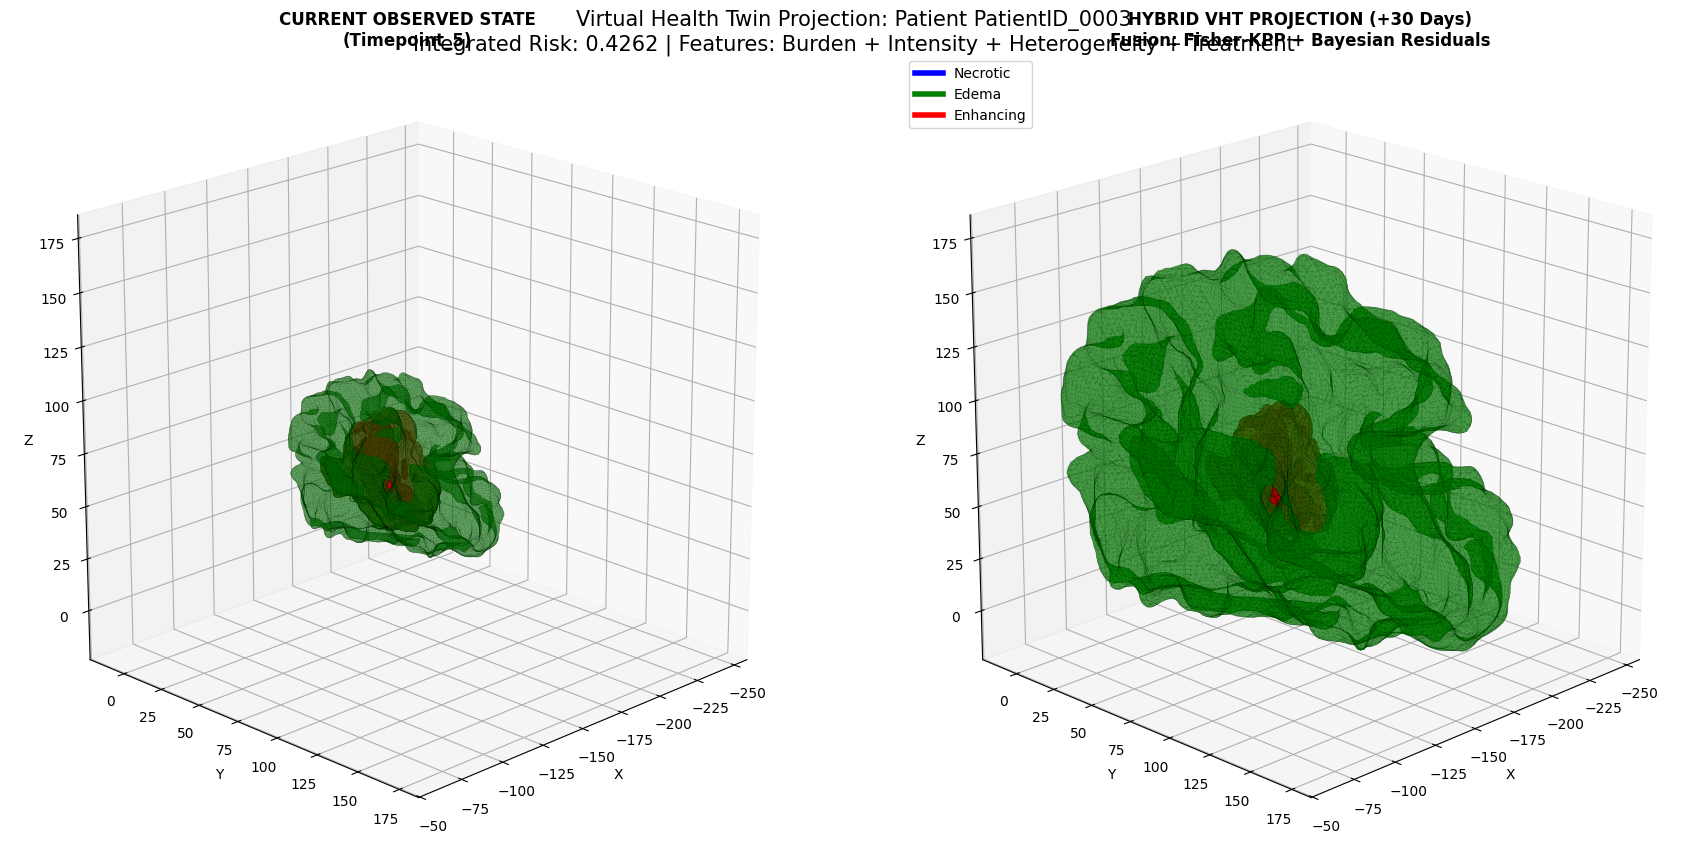

In [6]:
print("GP-only projection")
visualize_vht_3d_prediction(patient_idx=0, days=30, mode="gp")

Hybrid GP + CNF projection


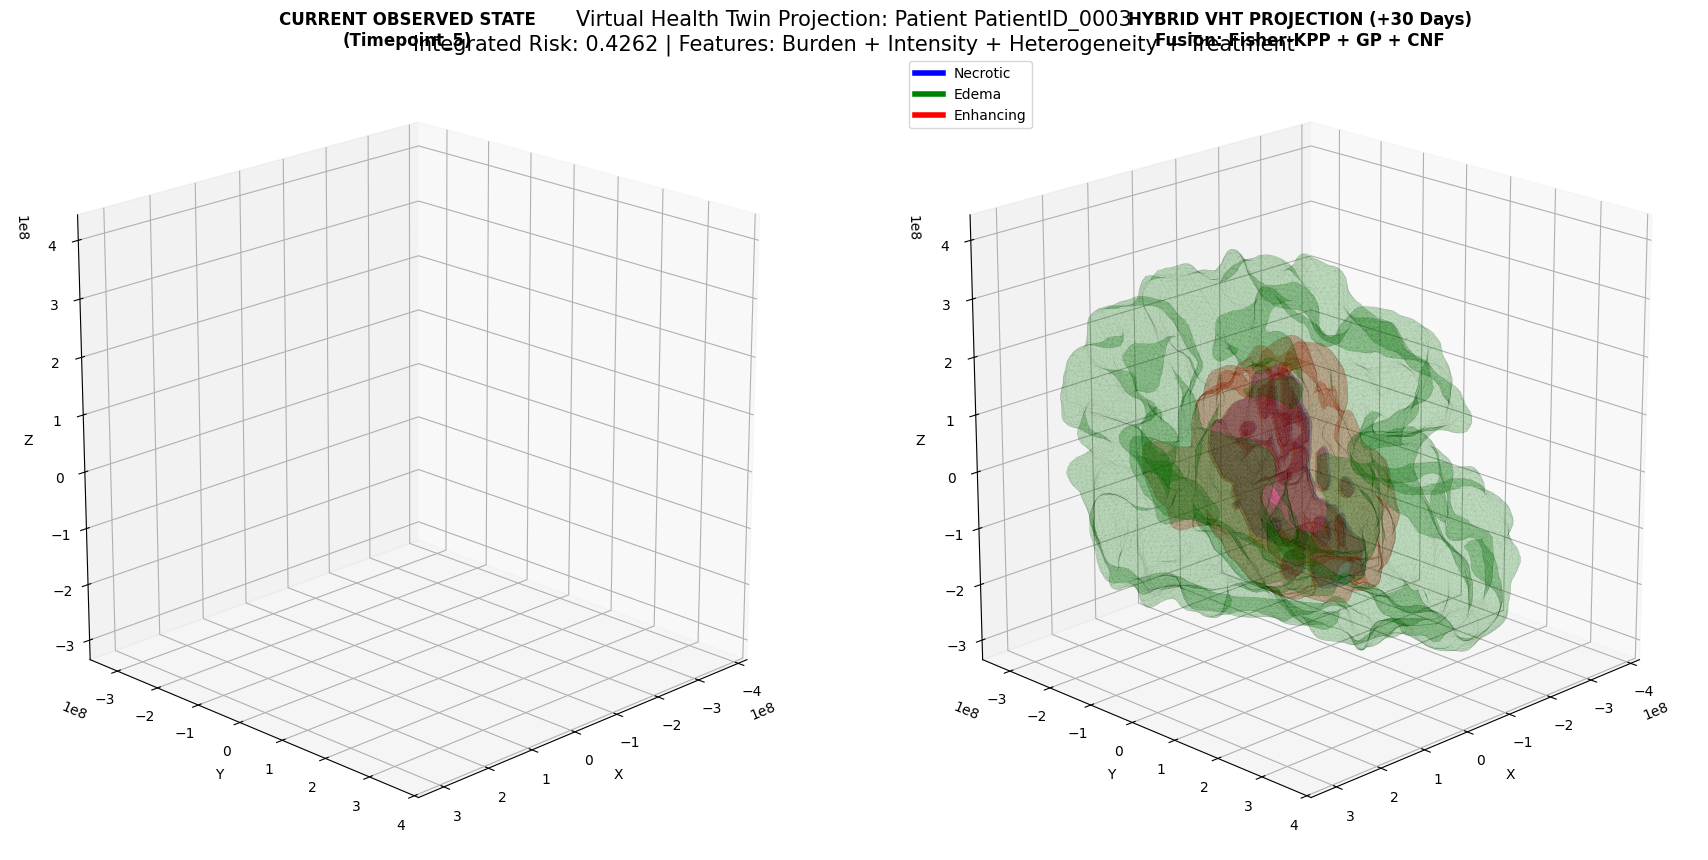

In [7]:
print("Hybrid GP + CNF projection")
visualize_vht_3d_prediction(patient_idx=0, days=30, mode="hybrid")

In [8]:
chemo_day=float(df_vht.iloc[0][' Number of days from Diagnosis to Initial Chemo Therapy Start date'])
print(f"Patient 1 Chemo Start Day: {chemo_day}")

Patient 1 Chemo Start Day: 26.0
